<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/capacity_and_bottleneck_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capacity and bottleneck analysis with NeqSim

**From equipment utilization snapshots to a reproducible debottlenecking study**

This notebook demonstrates how NeqSim converts a converged process model and mechanical
design limits into equipment utilizations, an active bottleneck, throughput capacity, and
transparent debottlenecking scenarios.

## Audience, prerequisites, and learning objectives

This tutorial is for process engineers, engineering students, and digital-twin developers.
You should be comfortable with Python tables and basic compressor and piping concepts.

By the end, you will be able to:

1. construct a natural-gas feed with the SRK equation of state;
2. connect a stream, compressor, and export pipe in `ProcessSystem`;
3. initialize and configure equipment mechanical-design limits;
4. retrieve structured utilization and bottleneck snapshots;
5. inspect individual power, velocity, LOF, FRMS, and AIV constraints;
6. preserve and extend the original throughput sweep;
7. calculate the maximum feasible flow by a bounded search;
8. compare compressor and pipe debottlenecking scenarios;
9. verify mass and compressor-energy closure; and
10. export a reusable capacity report for engineering workflows.

## Preservation inventory

The previous notebook contained four substantive example groups, all preserved here:

1. create and flash the original six-component natural gas;
2. build the original feed-compressor-pipe process and set a 2,500 kW design power;
3. read the utilization snapshot and identify the bottleneck; and
4. screen the original seven feed rates from 6,000 to 48,000 kg/h.

The previous notebook contained **zero figures**. Six new technical figures are added
without replacing prior visual content. Stale NeqSim 3.15 installation output is removed;
all numerical outputs are recalculated with the current tested release.

In [1]:
import importlib.util
import subprocess
import sys


required_packages = {
    "neqsim": "neqsim",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}
missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            *missing_packages,
        ]
    )

In [2]:
import hashlib
import json
import platform
import subprocess
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import FancyBboxPatch
from neqsim import jneqsim
from neqsim.thermo import TPflash


COLORS = {
    "blue": "#0072B2",
    "orange": "#D55E00",
    "green": "#009E73",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "grey": "#666666",
}
plt.rcParams.update(
    {
        "figure.dpi": 115,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 10,
    }
)

java_version = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    text=True,
    check=True,
).stderr.splitlines()[0]
runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [
            version("neqsim"),
            platform.python_version(),
            java_version,
        ],
    }
)
display(runtime_table)

,Runtime,Version
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,"openjdk version ""17.0.19"" 2026-04-21"


## 1. Engineering context

A converged process model predicts operating conditions. Capacity analysis adds a second
question: how close is each unit to its design or operational limit? The active bottleneck
is the enabled constraint with the largest utilization.

This screening example compresses natural gas from 45 to 100 bara and sends it through a
short export-pipe segment. Compressor power and pipe velocity provide two competing
capacity limits. The example is deliberately compact so the API and engineering logic are
visible.

## 2. Governing balances

With no side stream, the steady-state mass balance is:

$$
\dot{m}_{feed}=\dot{m}_{pipe,out}
$$

Mass flow $\dot{m}$ is reported in kg/h. The compressor energy balance is:

$$
\dot{W}=\dot{m}(h_{out}-h_{in})
$$

Shaft power $\dot{W}$ is in W, mass flow is in kg/s, and specific enthalpy $h$ is in J/kg.

## 3. Utilization and bottlenecks

For an enabled capacity constraint $j$, utilization is:

$$
U_j=\frac{x_j}{x_{j,design}}
$$

The current value $x_j$ and design value $x_{j,design}$ must use compatible units.
A utilization of 1.0 means 100%. The process bottleneck is:

$$
U_{max}=\max_j U_j
$$

A design is feasible when every enabled constraint has $U_j\leq1$. Disabled constraints
may still appear in the snapshot for context, but they do not determine feasibility.

## 4. Assumptions and validity limits

- Pressure is absolute and reported in bara.
- Flow is mass flow in kg/h; actual velocity is calculated by NeqSim.
- The compressor uses a fixed 78% isentropic efficiency, not a vendor map.
- The compressor power limit is 2,500 kW in the base case.
- The pipe is 100 m long, horizontal, 0.15 m internal diameter, with 0.01 mm roughness.
- The built-in pipe design velocity is 20 m/s.
- LOF, FRMS, and AIV are retained from NeqSim's pipe capacity snapshot, but this synthetic
  case has no project-specific acoustic or vibration qualification.

Results are screening evidence, not a replacement for vendor curves, stress analysis,
vibration assessment, relief review, or facility design approval.

In [3]:
component_mole_fractions = {
    "nitrogen": 0.01,
    "CO2": 0.02,
    "methane": 0.86,
    "ethane": 0.07,
    "propane": 0.03,
    "n-butane": 0.01,
}
base_design = {
    "feed_temperature_c": 25.0,
    "feed_pressure_bara": 45.0,
    "feed_flow_kg_h": 12000.0,
    "compressor_outlet_pressure_bara": 100.0,
    "compressor_isentropic_efficiency": 0.78,
    "compressor_design_power_kw": 2500.0,
    "pipe_length_m": 100.0,
    "pipe_diameter_m": 0.15,
    "pipe_roughness_m": 1.0e-5,
    "pipe_elevation_m": 0.0,
    "mixing_rule": "classic",
}

composition_table = pd.DataFrame(
    {
        "Component": component_mole_fractions.keys(),
        "Mole fraction [-]": component_mole_fractions.values(),
    }
)
design_table = pd.DataFrame(
    [
        ("Feed temperature", 25.0, "°C"),
        ("Feed pressure", 45.0, "bara"),
        ("Base flow", 12000.0, "kg/h"),
        ("Compressor outlet pressure", 100.0, "bara"),
        ("Compressor isentropic efficiency", 0.78, "-"),
        ("Compressor design power", 2500.0, "kW"),
        ("Pipe length", 100.0, "m"),
        ("Pipe internal diameter", 0.15, "m"),
        ("Pipe roughness", 0.01, "mm"),
    ],
    columns=["Quantity", "Value", "Unit"],
)

display(composition_table)
display(design_table)

,Component,Mole fraction [-]
0,nitrogen,0.01
1,CO2,0.02
2,methane,0.86
3,ethane,0.07
4,propane,0.03
5,n-butane,0.01


,Quantity,Value,Unit
0,Feed temperature,25.00,°C
1,Feed pressure,45.00,bara
2,Base flow,12000.00,kg/h
3,Compressor outlet pressure,100.00,bara
4,Compressor isentropic efficiency,0.78,-
5,Compressor design power,2500.00,kW
6,Pipe length,100.00,m
7,Pipe internal diameter,0.15,m
8,Pipe roughness,0.01,mm


In [4]:
case_definition = {
    "composition": component_mole_fractions,
    "base_design": base_design,
}
canonical_case_json = json.dumps(
    case_definition,
    sort_keys=True,
    separators=(",", ":"),
)
case_fingerprint = hashlib.sha256(
    canonical_case_json.encode("utf-8")
).hexdigest()
composition_sum = sum(component_mole_fractions.values())

print(f"Case fingerprint: {case_fingerprint}")
print(f"Composition sum: {composition_sum:.12f}")

Case fingerprint: b0120ec5ec79075d2bd7ea6e4358eeaa69419c10d2cf8f6251de1ceb76bc4d34
Composition sum: 1.000000000000


## 5. NeqSim model and API choices

SRK with the classic mixing rule is a common natural-gas screening model. The feed is
flashed at its operating state before creating equipment. The notebook uses direct current
NeqSim classes because mechanical design and utilization snapshots expose more functionality
than a minimal wrapper:

- `Stream` represents the feed;
- `Compressor` calculates real-gas outlet state and power;
- `PipeBeggsAndBrills` calculates pressure loss and capacity indicators;
- `ProcessSystem` executes the connected units;
- `initAllMechanicalDesigns()` initializes design objects; and
- `getUtilizationSnapshotJson()` returns structured capacity evidence.

In [5]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos


def make_gas(temperature_c=25.0, pressure_bara=45.0):
    fluid = SystemSrkEos(
        temperature_c + 273.15,
        pressure_bara,
    )

    for component_name, mole_fraction in component_mole_fractions.items():
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule(base_design["mixing_rule"])
    TPflash(fluid)
    fluid.initProperties()
    return fluid

In [6]:
feed_fluid = make_gas()
feed_property_table = pd.DataFrame(
    [
        {
            "Temperature [°C]": feed_fluid.getTemperature("C"),
            "Pressure [bara]": feed_fluid.getPressure("bara"),
            "Molar mass [kg/mol]": feed_fluid.getMolarMass("kg/mol"),
            "Density [kg/m³]": feed_fluid.getDensity("kg/m3"),
            "Enthalpy [kJ/kg]": (
                feed_fluid.getEnthalpy("J/kg") / 1000.0
            ),
            "Compressibility factor [-]": feed_fluid.getZ(),
        }
    ]
)
display(feed_property_table)

,Temperature [°C],Pressure [bara],Molar mass [kg/mol],Density [kg/m³],Enthalpy [kJ/kg],Compressibility factor [-]
0,25.0,45.0,0.018966,38.436406,-2.618472,0.897712


The feed properties are retrieved with explicit units and retained as part of the executed
notebook. A fresh fluid is created for every independently evaluated equipment design so
the study does not depend on hidden state.

## 6. Process topology

The original feed-compressor-pipe topology is preserved. The diagram adds the capacity
variables that will be read from the NeqSim utilization snapshot.

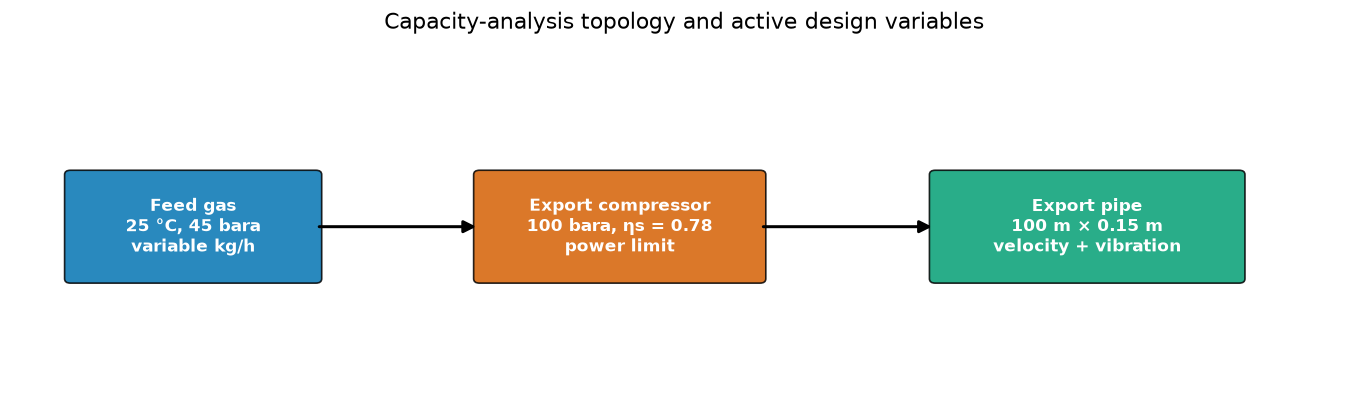

In [7]:
figure, axis = plt.subplots(figsize=(11.5, 3.5))
axis.set_xlim(0.0, 11.5)
axis.set_ylim(0.0, 4.0)
axis.axis("off")

boxes = [
    (
        0.5,
        1.35,
        2.1,
        1.2,
        "Feed gas\n25 °C, 45 bara\nvariable kg/h",
        "blue",
    ),
    (
        4.0,
        1.35,
        2.4,
        1.2,
        "Export compressor\n100 bara, ηs = 0.78\npower limit",
        "orange",
    ),
    (
        7.9,
        1.35,
        2.6,
        1.2,
        "Export pipe\n100 m × 0.15 m\nvelocity + vibration",
        "green",
    ),
]

for x_value, y_value, width, height, label, colour_key in boxes:
    box = FancyBboxPatch(
        (x_value, y_value),
        width,
        height,
        boxstyle="round,pad=0.05",
        facecolor=COLORS[colour_key],
        edgecolor="black",
        alpha=0.84,
    )
    axis.add_patch(box)
    axis.text(
        x_value + width / 2.0,
        y_value + height / 2.0,
        label,
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )

for start_point, end_point in [
    ((2.6, 1.95), (4.0, 1.95)),
    ((6.4, 1.95), (7.9, 1.95)),
]:
    axis.add_patch(
        FancyArrowPatch(
            start_point,
            end_point,
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.8,
            color="black",
        )
    )

axis.set_title(
    "Capacity-analysis topology and active design variables",
    fontsize=13,
    pad=12,
)
plt.tight_layout()
plt.show()

## 7. Build the preserved compressor and pipe case

The function below retains the original equipment types, dimensions, and power limit while
adding explicit compressor efficiency, pipe roughness, and elevation. It returns every
named object so larger engineering workflows can reuse the process.

In [8]:
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
PipeBeggsAndBrills = (
    jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
)
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


def build_capacity_case(
    flow_kg_h=12000.0,
    pipe_diameter_m=0.15,
    compressor_design_power_kw=2500.0,
):
    fluid = make_gas(
        temperature_c=base_design["feed_temperature_c"],
        pressure_bara=base_design["feed_pressure_bara"],
    )
    feed = Stream("Feed gas", fluid)
    feed.setFlowRate(flow_kg_h, "kg/hr")

    compressor = Compressor("Export compressor", feed)
    compressor.setOutletPressure(
        base_design["compressor_outlet_pressure_bara"],
        "bara",
    )
    compressor.setIsentropicEfficiency(
        base_design["compressor_isentropic_efficiency"]
    )

    export_pipe = PipeBeggsAndBrills(
        "Export pipe",
        compressor.getOutletStream(),
    )
    export_pipe.setLength(base_design["pipe_length_m"])
    export_pipe.setDiameter(pipe_diameter_m)
    export_pipe.setPipeWallRoughness(
        base_design["pipe_roughness_m"]
    )
    export_pipe.setElevation(base_design["pipe_elevation_m"])

    process = ProcessSystem()

    for unit_operation in [
        feed,
        compressor,
        export_pipe,
    ]:
        process.add(unit_operation)

    process.run()
    process.initAllMechanicalDesigns()
    compressor.getMechanicalDesign().setMaxDesignPower(
        compressor_design_power_kw
    )
    process.run()

    return {
        "process": process,
        "feed": feed,
        "compressor": compressor,
        "pipe": export_pipe,
    }

In [9]:
base_case = build_capacity_case()
base_process = base_case["process"]
base_feed = base_case["feed"]
base_compressor = base_case["compressor"]
base_pipe = base_case["pipe"]

base_result_table = pd.DataFrame(
    [
        {
            "Feed flow [kg/h]": base_feed.getFlowRate("kg/hr"),
            "Compressor inlet [bara]": (
                base_feed.getPressure("bara")
            ),
            "Compressor outlet [bara]": (
                base_compressor.getOutletStream().getPressure(
                    "bara"
                )
            ),
            "Compressor outlet [°C]": (
                base_compressor.getOutletStream().getTemperature(
                    "C"
                )
            ),
            "Compressor power [kW]": (
                base_compressor.getPower("kW")
            ),
            "Pipe outlet [bara]": (
                base_pipe.getOutletPressure()
            ),
            "Pipe pressure drop [bar]": (
                base_compressor.getOutletStream().getPressure(
                    "bara"
                )
                - base_pipe.getOutletPressure()
            ),
        }
    ]
)
display(base_result_table)

,Feed flow [kg/h],Compressor inlet [bara],Compressor outlet [bara],Compressor outlet [°C],Compressor power [kW],Pipe outlet [bara],Pipe pressure drop [bar]
0,12000.0,45.0,100.0,96.237467,444.014648,99.978287,0.021713


The process solves a real thermodynamic compressor state followed by a hydraulic pressure
drop. The utilization API is not an isolated arithmetic example: it is attached to the
converged process and its initialized mechanical-design objects.

## 8. Conservation and energy audit

The process has no side stream, so inlet and pipe-outlet mass flow should match. Compressor
power is reconstructed from the gas enthalpy rise to verify units and sign.

In [10]:
compressor_inlet = base_feed
compressor_outlet = base_compressor.getOutletStream()
mass_flow_kg_s = compressor_inlet.getFlowRate("kg/sec")
enthalpy_rate_change_w = mass_flow_kg_s * (
    compressor_outlet.getFluid().getEnthalpy("J/kg")
    - compressor_inlet.getFluid().getEnthalpy("J/kg")
)
compressor_energy_residual_w = (
    base_compressor.getPower("W") - enthalpy_rate_change_w
)
process_mass_residual_kg_h = (
    base_feed.getFlowRate("kg/hr")
    - base_pipe.getOutletStream().getFlowRate("kg/hr")
)
audit_table = pd.DataFrame(
    [
        {
            "Check": "Process mass balance",
            "Residual": process_mass_residual_kg_h,
            "Unit": "kg/h",
        },
        {
            "Check": "Compressor energy balance",
            "Residual": compressor_energy_residual_w,
            "Unit": "W",
        },
    ]
)
display(audit_table)

,Check,Residual,Unit
0,Process mass balance,0.000000e+00,kg/h
1,Compressor energy balance,-5.820766e-11,W


## 9. Read the utilization snapshot

This preserves the original snapshot example. `getAutomation()` exposes the automation
facade, while `getUtilizationSnapshot()` and `getUtilizationSnapshotJson()` return the same
capacity state in structured form. The snapshot distinguishes enabled and disabled
constraints and reports the active bottleneck.

In [11]:
automation = base_process.getAutomation()
base_snapshot = json.loads(
    str(automation.getUtilizationSnapshot())
)
direct_snapshot = json.loads(
    str(base_process.getUtilizationSnapshotJson())
)

print(
    json.dumps(
        base_snapshot.get("bottleneck"),
        indent=2,
    )
)
print(
    "Snapshot schema:",
    base_snapshot.get("schemaVersion"),
)
print(
    "Automation and direct snapshots agree:",
    base_snapshot == direct_snapshot,
)

{
  "name": "Export compressor",
  "utilization": 0.17760585933452921,
  "utilizationPercent": 17.760585933452923,
  "limitingConstraint": "power"
}
Snapshot schema: 1.0
Automation and direct snapshots agree: True


In [12]:
unit_utilization_table = pd.DataFrame(
    base_snapshot.get("units", [])
)
constraint_rows = []

for unit_record in base_snapshot.get("units", []):
    for constraint_record in unit_record.get("constraints", []):
        constraint_rows.append(
            {
                "Unit": unit_record["name"],
                "Constraint": constraint_record["name"],
                "Current": constraint_record["current"],
                "Design": constraint_record["design"],
                "Unit of measure": constraint_record["unit"],
                "Utilization [%]": constraint_record[
                    "utilizationPercent"
                ],
                "Enabled": constraint_record["enabled"],
                "Violated": constraint_record["violated"],
            }
        )

constraint_table = pd.DataFrame(constraint_rows)
display(
    unit_utilization_table[
        [
            "name",
            "type",
            "maxUtilizationPercent",
            "limitingConstraint",
            "feasible",
        ]
    ]
)
display(constraint_table)

,name,type,maxUtilizationPercent,limitingConstraint,feasible
0,Feed gas,Stream,0.000000,NaN,True
1,Export compressor,Compressor,17.760586,power,True
2,Export pipe,PipeBeggsAndBrills,14.187609,velocity,True


,Unit,Constraint,Current,Design,Unit of measure,Utilization [%],Enabled,Violated
0,Export compressor,speed,3.000000e+03,30000.0,RPM,1.000000e+01,False,False
1,Export compressor,power,1.776059e+01,100.0,kW,1.776059e+01,True,False
2,Export compressor,ratedPower,1.776059e+01,100.0,%,1.776059e+01,True,False
3,Export compressor,surgeMargin,1.000000e+02,100.0,%,1.000000e+02,False,False
4,Export compressor,stonewallMargin,1.000000e+02,100.0,%,1.000000e+02,False,False
5,Export pipe,velocity,2.837522e+00,20.0,m/s,1.418761e+01,True,False
6,Export pipe,LOF,5.710620e-04,1.0,-,5.710620e-02,True,False
7,Export pipe,FRMS,0.000000e+00,500.0,-,0.000000e+00,True,False
8,Export pipe,AIV,8.812705e-18,25.0,kW,3.525082e-17,True,False


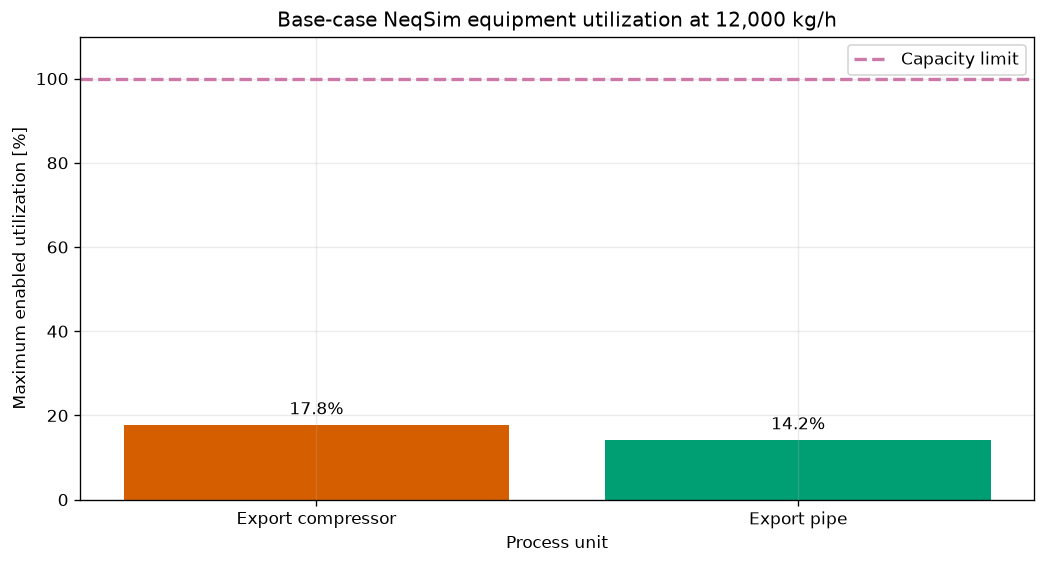

In [13]:
plotted_units = unit_utilization_table[
    unit_utilization_table["maxUtilizationPercent"] > 0.0
]
figure, axis = plt.subplots(figsize=(8.8, 4.8))
bars = axis.bar(
    plotted_units["name"],
    plotted_units["maxUtilizationPercent"],
    color=[COLORS["orange"], COLORS["green"]],
)
axis.axhline(
    100.0,
    color=COLORS["purple"],
    linewidth=2.0,
    linestyle="--",
    label="Capacity limit",
)
axis.bar_label(
    bars,
    fmt="%.1f%%",
    padding=4,
)
axis.set_xlabel("Process unit")
axis.set_ylabel("Maximum enabled utilization [%]")
axis.set_title(
    "Base-case NeqSim equipment utilization at 12,000 kg/h"
)
axis.legend()
axis.set_ylim(
    0.0,
    max(110.0, plotted_units["maxUtilizationPercent"].max() * 1.25),
)
plt.tight_layout()
plt.show()

The base compressor is limited by power and the pipe by velocity. The compressor is the
process bottleneck because its utilization is slightly higher. LOF, FRMS, AIV, surge, and
stonewall records remain visible, but disabled constraints do not control feasibility.

## 10. Preserve and extend the original rate sweep

The original seven rates are retained exactly. Three higher rates are added so the
transition through 100% utilization is visible. The same process objects are rerun after
changing only the feed-flow input. A fresh process is built for each rate so every case is
fully initialized and independent of evaluation order.

In [14]:
original_flow_rates_kg_h = [
    6000.0,
    9000.0,
    12000.0,
    15000.0,
    18000.0,
    25000.0,
    48000.0,
]
extended_flow_rates_kg_h = [
    60000.0,
    72000.0,
    84000.0,
]
flow_rates_kg_h = (
    original_flow_rates_kg_h + extended_flow_rates_kg_h
)
rate_rows = []

for flow_kg_h in flow_rates_kg_h:
    rate_case = build_capacity_case(
        flow_kg_h=flow_kg_h,
        pipe_diameter_m=base_design["pipe_diameter_m"],
        compressor_design_power_kw=base_design[
            "compressor_design_power_kw"
        ],
    )
    snapshot = json.loads(
        str(
            rate_case["process"].getUtilizationSnapshotJson()
        )
    )
    unit_lookup = {
        unit_record["name"]: unit_record
        for unit_record in snapshot["units"]
    }
    bottleneck = snapshot.get("bottleneck") or {}
    rate_rows.append(
        {
            "Flow [kg/h]": flow_kg_h,
            "Bottleneck": bottleneck.get("name"),
            "Bottleneck constraint": bottleneck.get(
                "limitingConstraint"
            ),
            "Maximum utilization [%]": bottleneck.get(
                "utilizationPercent"
            ),
            "Compressor utilization [%]": unit_lookup[
                "Export compressor"
            ]["maxUtilizationPercent"],
            "Pipe utilization [%]": unit_lookup[
                "Export pipe"
            ]["maxUtilizationPercent"],
            "Overloaded": snapshot["anyOverloaded"],
            "Compressor power [kW]": (
                rate_case["compressor"].getPower("kW")
            ),
            "Pipe outlet pressure [bara]": (
                rate_case["pipe"].getOutletPressure()
            ),
        }
    )

rate_sweep = pd.DataFrame(rate_rows)
display(rate_sweep)

,Flow [kg/h],Bottleneck,Bottleneck constraint,Maximum utilization [%],Compressor utilization [%],Pipe utilization [%],Overloaded,Compressor power [kW],Pipe outlet pressure [bara]
0,6000.0,Export compressor,power,8.880293,8.880293,7.092629,False,222.007324,99.994232
1,9000.0,Export compressor,power,13.320439,13.320439,10.639687,False,333.010986,99.987510
2,12000.0,Export compressor,power,17.760586,17.760586,14.187609,False,444.014648,99.978287
3,15000.0,Export compressor,power,22.200732,22.200732,17.736671,False,555.018310,99.966572
4,18000.0,Export compressor,power,26.640879,26.640879,21.287147,False,666.021973,99.952368
5,25000.0,Export compressor,power,37.001221,37.001221,29.578647,False,925.030517,99.909555
6,48000.0,Export compressor,power,71.042344,71.042344,56.930808,False,1776.058593,99.673435
7,60000.0,Export compressor,power,88.802930,88.802930,71.298417,False,2220.073242,99.491950
8,72000.0,Export compressor,power,106.563516,106.563516,85.756676,True,2664.087890,99.270273
9,84000.0,Export compressor,power,124.324102,124.324102,100.324755,True,3108.102538,99.008181


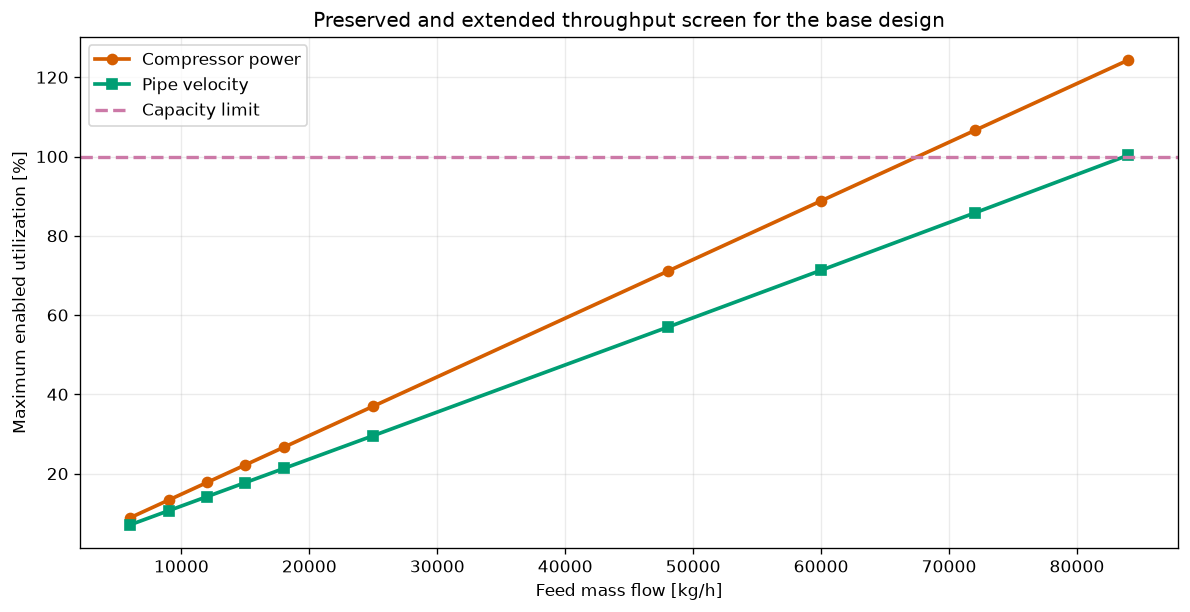

In [15]:
figure, axis = plt.subplots(figsize=(10.0, 5.2))
axis.plot(
    rate_sweep["Flow [kg/h]"],
    rate_sweep["Compressor utilization [%]"],
    marker="o",
    linewidth=2.2,
    color=COLORS["orange"],
    label="Compressor power",
)
axis.plot(
    rate_sweep["Flow [kg/h]"],
    rate_sweep["Pipe utilization [%]"],
    marker="s",
    linewidth=2.2,
    color=COLORS["green"],
    label="Pipe velocity",
)
axis.axhline(
    100.0,
    color=COLORS["purple"],
    linewidth=2.0,
    linestyle="--",
    label="Capacity limit",
)
axis.set_xlabel("Feed mass flow [kg/h]")
axis.set_ylabel("Maximum enabled utilization [%]")
axis.set_title(
    "Preserved and extended throughput screen for the base design"
)
axis.legend()
plt.tight_layout()
plt.show()

Utilization rises smoothly with throughput. The compressor remains the active constraint for
the 0.15 m base pipe until the pipe approaches its own velocity limit. A rate above the first
100% crossing is outside the stated base design even if the thermodynamic process still
converges.

## 11. Calculate the throughput capacity

A bounded bisection search finds the largest flow with maximum enabled utilization no
greater than 100%. Each iteration reruns NeqSim, reads the structured snapshot, and retains
the limiting equipment and constraint.

In [16]:
def evaluate_capacity_state(
    flow_kg_h,
    pipe_diameter_m,
    compressor_design_power_kw,
):
    case_objects = build_capacity_case(
        flow_kg_h=flow_kg_h,
        pipe_diameter_m=pipe_diameter_m,
        compressor_design_power_kw=(
            compressor_design_power_kw
        ),
    )
    snapshot = json.loads(
        str(
            case_objects["process"].getUtilizationSnapshotJson()
        )
    )
    bottleneck = snapshot.get("bottleneck") or {}
    return {
        "flow_kg_h": flow_kg_h,
        "maximum_utilization": bottleneck.get(
            "utilization",
            0.0,
        ),
        "maximum_utilization_percent": bottleneck.get(
            "utilizationPercent",
            0.0,
        ),
        "bottleneck": bottleneck.get("name"),
        "limiting_constraint": bottleneck.get(
            "limitingConstraint"
        ),
        "snapshot": snapshot,
        "case_objects": case_objects,
    }


def find_capacity_limit(
    pipe_diameter_m,
    compressor_design_power_kw,
    lower_flow_kg_h=5000.0,
    upper_flow_kg_h=110000.0,
    iterations=14,
):
    lower_state = evaluate_capacity_state(
        flow_kg_h=lower_flow_kg_h,
        pipe_diameter_m=pipe_diameter_m,
        compressor_design_power_kw=(
            compressor_design_power_kw
        ),
    )
    upper_state = evaluate_capacity_state(
        flow_kg_h=upper_flow_kg_h,
        pipe_diameter_m=pipe_diameter_m,
        compressor_design_power_kw=(
            compressor_design_power_kw
        ),
    )

    if lower_state["maximum_utilization"] > 1.0:
        raise ValueError("Lower capacity bound is already overloaded.")

    if upper_state["maximum_utilization"] <= 1.0:
        raise ValueError("Upper capacity bound is not overloaded.")

    lower_flow = lower_flow_kg_h
    upper_flow = upper_flow_kg_h

    for _ in range(iterations):
        midpoint_flow = 0.5 * (lower_flow + upper_flow)
        midpoint_state = evaluate_capacity_state(
            flow_kg_h=midpoint_flow,
            pipe_diameter_m=pipe_diameter_m,
            compressor_design_power_kw=(
                compressor_design_power_kw
            ),
        )

        if midpoint_state["maximum_utilization"] <= 1.0:
            lower_flow = midpoint_flow
            lower_state = midpoint_state
        else:
            upper_flow = midpoint_flow
            upper_state = midpoint_state

    return {
        "capacity_flow_kg_h": lower_flow,
        "first_overloaded_flow_kg_h": upper_flow,
        "capacity_state": lower_state,
        "overloaded_state": upper_state,
    }

In [17]:
base_capacity = find_capacity_limit(
    pipe_diameter_m=base_design["pipe_diameter_m"],
    compressor_design_power_kw=base_design[
        "compressor_design_power_kw"
    ],
)
base_capacity_table = pd.DataFrame(
    [
        {
            "Capacity [kg/h]": base_capacity[
                "capacity_flow_kg_h"
            ],
            "First overloaded flow [kg/h]": base_capacity[
                "first_overloaded_flow_kg_h"
            ],
            "Bottleneck": base_capacity["capacity_state"][
                "bottleneck"
            ],
            "Constraint": base_capacity["capacity_state"][
                "limiting_constraint"
            ],
            "Utilization [%]": base_capacity[
                "capacity_state"
            ]["maximum_utilization_percent"],
        }
    ]
)
display(base_capacity_table)

,Capacity [kg/h],First overloaded flow [kg/h],Bottleneck,Constraint,Utilization [%]
0,67561.645508,67568.054199,Export compressor,power,99.994534


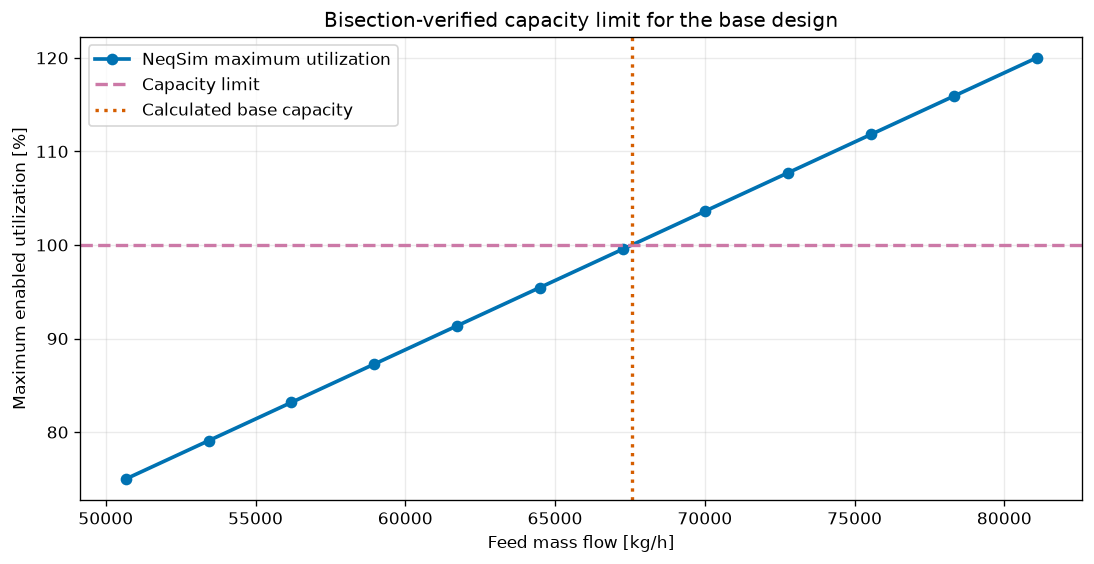

In [18]:
capacity_window_flows = np.linspace(
    0.75 * base_capacity["capacity_flow_kg_h"],
    1.20 * base_capacity["capacity_flow_kg_h"],
    12,
)
capacity_window_rows = []

for flow_kg_h in capacity_window_flows:
    state = evaluate_capacity_state(
        flow_kg_h=float(flow_kg_h),
        pipe_diameter_m=base_design["pipe_diameter_m"],
        compressor_design_power_kw=base_design[
            "compressor_design_power_kw"
        ],
    )
    capacity_window_rows.append(
        {
            "Flow [kg/h]": flow_kg_h,
            "Maximum utilization [%]": state[
                "maximum_utilization_percent"
            ],
        }
    )

capacity_window = pd.DataFrame(capacity_window_rows)
figure, axis = plt.subplots(figsize=(9.2, 4.8))
axis.plot(
    capacity_window["Flow [kg/h]"],
    capacity_window["Maximum utilization [%]"],
    marker="o",
    linewidth=2.2,
    color=COLORS["blue"],
    label="NeqSim maximum utilization",
)
axis.axhline(
    100.0,
    color=COLORS["purple"],
    linewidth=2.0,
    linestyle="--",
    label="Capacity limit",
)
axis.axvline(
    base_capacity["capacity_flow_kg_h"],
    color=COLORS["orange"],
    linewidth=2.0,
    linestyle=":",
    label="Calculated base capacity",
)
axis.set_xlabel("Feed mass flow [kg/h]")
axis.set_ylabel("Maximum enabled utilization [%]")
axis.set_title(
    "Bisection-verified capacity limit for the base design"
)
axis.legend()
plt.tight_layout()
plt.show()

The lower result is the highest feasible bisection point; the next point is overloaded.
The small interval between them quantifies numerical search resolution. This is preferable
to assuming capacity scales exactly linearly when hydraulic constraints may be nonlinear.

## 12. Compressor-power and pipe-diameter design study

The next study evaluates sixteen independent equipment configurations. Each configuration
creates fresh NeqSim objects, initializes mechanical design, and runs the same bounded
capacity search. This reveals whether an apparent compressor bottleneck will simply move to
the pipe after an uprate.

In [19]:
pipe_diameters_m = [
    0.10,
    0.12,
    0.15,
    0.18,
]
compressor_power_limits_kw = [
    1500.0,
    2000.0,
    2500.0,
    3500.0,
]
capacity_design_rows = []

for pipe_diameter_m in pipe_diameters_m:
    for compressor_power_limit_kw in compressor_power_limits_kw:
        capacity_result = find_capacity_limit(
            pipe_diameter_m=pipe_diameter_m,
            compressor_design_power_kw=(
                compressor_power_limit_kw
            ),
        )
        capacity_design_rows.append(
            {
                "Pipe diameter [m]": pipe_diameter_m,
                "Compressor design power [kW]": (
                    compressor_power_limit_kw
                ),
                "Capacity [kg/h]": capacity_result[
                    "capacity_flow_kg_h"
                ],
                "Bottleneck": capacity_result[
                    "capacity_state"
                ]["bottleneck"],
                "Constraint": capacity_result[
                    "capacity_state"
                ]["limiting_constraint"],
            }
        )

capacity_design_space = pd.DataFrame(capacity_design_rows)
display(capacity_design_space)

,Pipe diameter [m],Compressor design power [kW],Capacity [kg/h],Bottleneck,Constraint
0,0.10,1500.0,36979.370117,Export pipe,velocity
1,0.10,2000.0,36979.370117,Export pipe,velocity
2,0.10,2500.0,36979.370117,Export pipe,velocity
3,0.10,3500.0,36979.370117,Export pipe,velocity
4,0.12,1500.0,40536.193848,Export compressor,power
5,0.12,2000.0,53424.072266,Export pipe,velocity
6,0.12,2500.0,53424.072266,Export pipe,velocity
7,0.12,3500.0,53424.072266,Export pipe,velocity
8,0.15,1500.0,40536.193848,Export compressor,power
9,0.15,2000.0,54052.124023,Export compressor,power


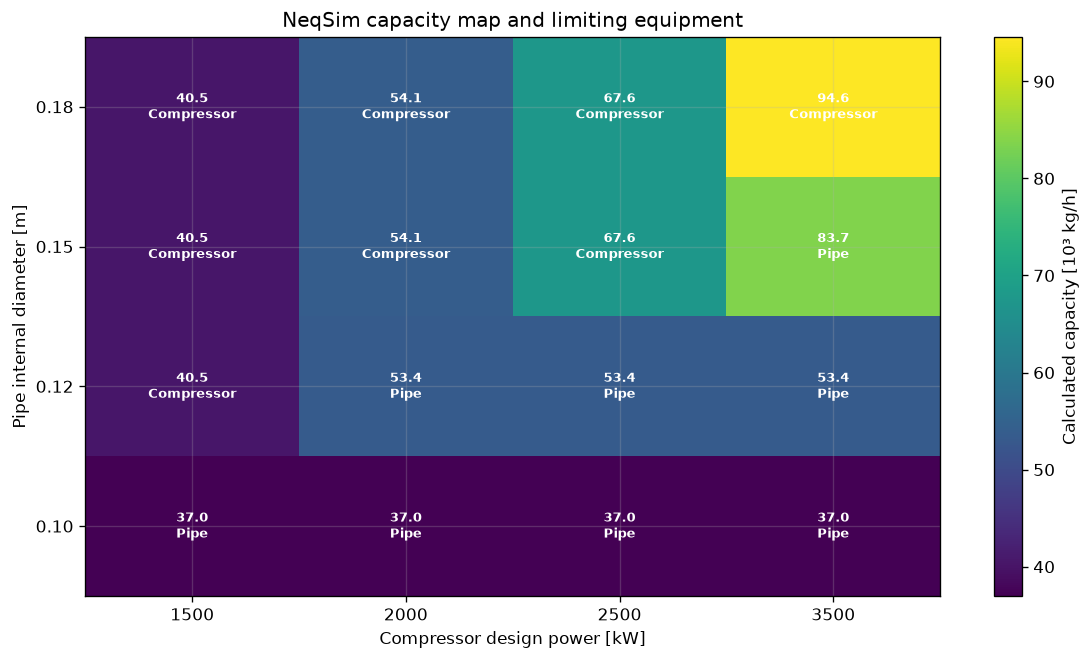

In [20]:
capacity_grid = capacity_design_space.pivot(
    index="Pipe diameter [m]",
    columns="Compressor design power [kW]",
    values="Capacity [kg/h]",
)
bottleneck_grid = capacity_design_space.pivot(
    index="Pipe diameter [m]",
    columns="Compressor design power [kW]",
    values="Bottleneck",
)

figure, axis = plt.subplots(figsize=(9.8, 5.6))
image = axis.imshow(
    capacity_grid.to_numpy() / 1000.0,
    aspect="auto",
    origin="lower",
    cmap="viridis",
)
colour_bar = figure.colorbar(image, ax=axis)
colour_bar.set_label("Calculated capacity [10³ kg/h]")
axis.set_xticks(
    np.arange(len(capacity_grid.columns)),
    [
        f"{power_limit:.0f}"
        for power_limit in capacity_grid.columns
    ],
)
axis.set_yticks(
    np.arange(len(capacity_grid.index)),
    [
        f"{pipe_diameter:.2f}"
        for pipe_diameter in capacity_grid.index
    ],
)
axis.set_xlabel("Compressor design power [kW]")
axis.set_ylabel("Pipe internal diameter [m]")
axis.set_title(
    "NeqSim capacity map and limiting equipment"
)

for row_index in range(len(capacity_grid.index)):
    for column_index in range(len(capacity_grid.columns)):
        capacity_value = capacity_grid.iloc[
            row_index,
            column_index,
        ]
        bottleneck_name = bottleneck_grid.iloc[
            row_index,
            column_index,
        ]
        bottleneck_label = (
            "Compressor"
            if bottleneck_name == "Export compressor"
            else "Pipe"
        )
        axis.text(
            column_index,
            row_index,
            f"{capacity_value / 1000.0:.1f}\n{bottleneck_label}",
            ha="center",
            va="center",
            color="white",
            fontsize=8,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

Increasing compressor power has no value when pipe velocity is already limiting. Likewise,
increasing pipe diameter does not raise capacity when compressor power remains the active
limit. The map makes bottleneck migration explicit and prevents isolated equipment changes
from being credited with unavailable plant capacity.

## 13. Debottlenecking candidates

Four transparent candidates are compared with the base case:

- a smaller 0.12 m pipe, retained as a diagnostic lower-capacity case;
- compressor uprate only;
- pipe enlargement only; and
- combined compressor and pipe modification.

These are capacity scenarios, not cost estimates.

In [21]:
candidate_definitions = [
    ("Smaller pipe diagnostic", 0.12, 2500.0),
    ("Base design", 0.15, 2500.0),
    ("Compressor uprate", 0.15, 3500.0),
    ("Pipe enlargement", 0.18, 2500.0),
    ("Combined modification", 0.18, 3500.0),
]
candidate_rows = []

for candidate_name, pipe_diameter_m, design_power_kw in (
    candidate_definitions
):
    candidate_result = find_capacity_limit(
        pipe_diameter_m=pipe_diameter_m,
        compressor_design_power_kw=design_power_kw,
    )
    candidate_rows.append(
        {
            "Candidate": candidate_name,
            "Pipe diameter [m]": pipe_diameter_m,
            "Design power [kW]": design_power_kw,
            "Capacity [kg/h]": candidate_result[
                "capacity_flow_kg_h"
            ],
            "Bottleneck": candidate_result[
                "capacity_state"
            ]["bottleneck"],
            "Constraint": candidate_result[
                "capacity_state"
            ]["limiting_constraint"],
        }
    )

candidate_table = pd.DataFrame(candidate_rows)
base_candidate_capacity = candidate_table.loc[
    candidate_table["Candidate"] == "Base design",
    "Capacity [kg/h]",
].iloc[0]
candidate_table["Capacity increase [%]"] = (
    100.0
    * (
        candidate_table["Capacity [kg/h]"]
        - base_candidate_capacity
    )
    / base_candidate_capacity
)
display(candidate_table)

,Candidate,Pipe diameter [m],Design power [kW],Capacity [kg/h],Bottleneck,Constraint,Capacity increase [%]
0,Smaller pipe diagnostic,0.12,2500.0,53424.072266,Export pipe,velocity,-20.925442
1,Base design,0.15,2500.0,67561.645508,Export compressor,power,0.000000
2,Compressor uprate,0.15,3500.0,83730.773926,Export pipe,velocity,23.932408
3,Pipe enlargement,0.18,2500.0,67561.645508,Export compressor,power,0.000000
4,Combined modification,0.18,3500.0,94587.097168,Export compressor,power,40.001174


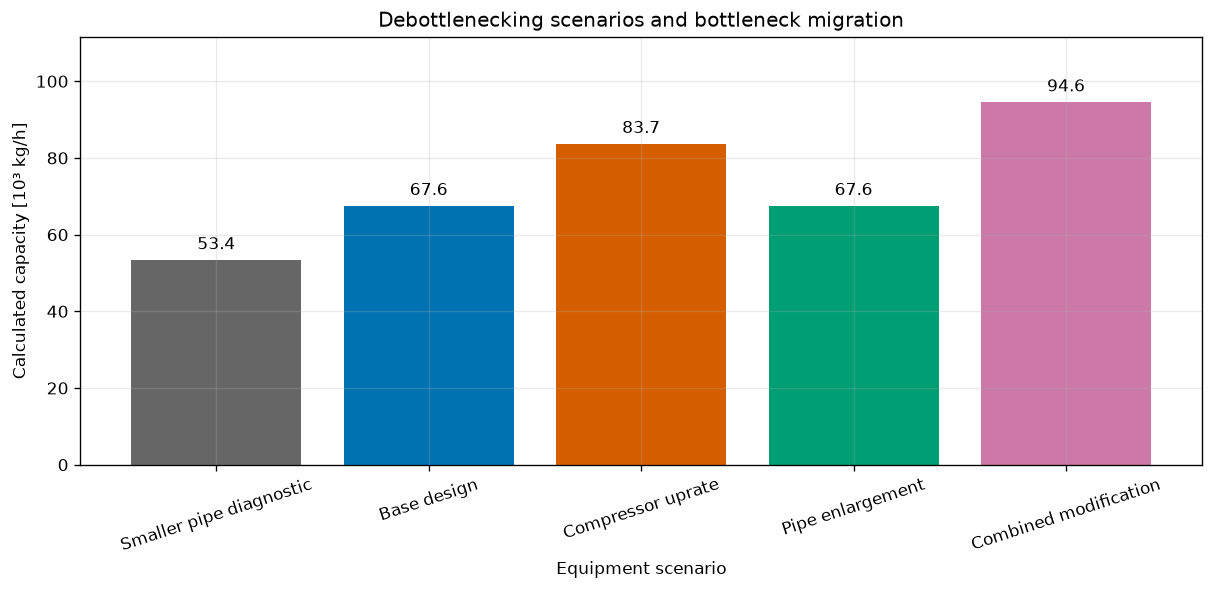

In [22]:
figure, axis = plt.subplots(figsize=(10.2, 5.0))
candidate_colours = [
    COLORS["grey"],
    COLORS["blue"],
    COLORS["orange"],
    COLORS["green"],
    COLORS["purple"],
]
bars = axis.bar(
    candidate_table["Candidate"],
    candidate_table["Capacity [kg/h]"] / 1000.0,
    color=candidate_colours,
)
axis.bar_label(
    bars,
    labels=[
        f"{capacity_value / 1000.0:.1f}"
        for capacity_value in candidate_table["Capacity [kg/h]"]
    ],
    padding=4,
)
axis.set_xlabel("Equipment scenario")
axis.set_ylabel("Calculated capacity [10³ kg/h]")
axis.set_title(
    "Debottlenecking scenarios and bottleneck migration"
)
axis.tick_params(
    axis="x",
    rotation=18,
)
axis.set_ylim(
    0.0,
    1.18 * candidate_table["Capacity [kg/h]"].max() / 1000.0,
)
plt.tight_layout()
plt.show()

The compressor-only and pipe-only cases demonstrate why a system view is necessary. The
combined case raises both relevant limits and is the only candidate intended to support the
final 90,000 kg/h target in this study.

## 14. Final application: verify a target-rate debottleneck

A fresh combined-modification process is run at 90,000 kg/h. The application retrieves the
full utilization snapshot, checks feasibility, lists automation-discovered units, closes
balances, and exports a fingerprinted JSON-ready result.

In [23]:
target_flow_kg_h = 90000.0
target_state = evaluate_capacity_state(
    flow_kg_h=target_flow_kg_h,
    pipe_diameter_m=0.18,
    compressor_design_power_kw=3500.0,
)
target_case = target_state["case_objects"]
target_snapshot = target_state["snapshot"]
target_unit_table = pd.DataFrame(target_snapshot["units"])
target_compressor = target_case["compressor"]
target_pipe = target_case["pipe"]
target_feed = target_case["feed"]
target_compressor_outlet = target_compressor.getOutletStream()
target_energy_residual_w = (
    target_compressor.getPower("W")
    - target_feed.getFlowRate("kg/sec")
    * (
        target_compressor_outlet.getFluid().getEnthalpy(
            "J/kg"
        )
        - target_feed.getFluid().getEnthalpy("J/kg")
    )
)
target_mass_residual_kg_h = (
    target_feed.getFlowRate("kg/hr")
    - target_pipe.getOutletStream().getFlowRate("kg/hr")
)

display(
    target_unit_table[
        [
            "name",
            "maxUtilizationPercent",
            "limitingConstraint",
            "feasible",
        ]
    ]
)
print(
    "Target bottleneck:",
    json.dumps(target_snapshot["bottleneck"], indent=2),
)

Target bottleneck: {
  "name": "Export compressor",
  "utilization": 0.9514599607206918,
  "utilizationPercent": 95.14599607206918,
  "limitingConstraint": "power"
}


,name,maxUtilizationPercent,limitingConstraint,feasible
0,Feed gas,0.000000,NaN,True
1,Export compressor,95.145996,power,True
2,Export pipe,74.219503,velocity,True


In [24]:
target_automation = target_case["process"].getAutomation()
discovered_units = [
    str(unit_name)
    for unit_name in list(target_automation.getUnitList())
]
capacity_report = {
    "case_fingerprint": case_fingerprint,
    "neqsim_version": version("neqsim"),
    "target_flow_kg_h": target_flow_kg_h,
    "selected_design": {
        "pipe_diameter_m": 0.18,
        "compressor_design_power_kw": 3500.0,
    },
    "results": {
        "compressor_power_kw": target_compressor.getPower("kW"),
        "pipe_outlet_pressure_bara": (
            target_pipe.getOutletPressure()
        ),
        "maximum_utilization_percent": target_state[
            "maximum_utilization_percent"
        ],
        "bottleneck": target_state["bottleneck"],
        "limiting_constraint": target_state[
            "limiting_constraint"
        ],
        "overloaded": target_snapshot["anyOverloaded"],
    },
    "validation": {
        "mass_residual_kg_h": target_mass_residual_kg_h,
        "compressor_energy_residual_w": (
            target_energy_residual_w
        ),
        "snapshot_schema": target_snapshot["schemaVersion"],
        "discovered_units": discovered_units,
    },
}
print(json.dumps(capacity_report, indent=2))

{
  "case_fingerprint": "b0120ec5ec79075d2bd7ea6e4358eeaa69419c10d2cf8f6251de1ceb76bc4d34",
  "neqsim_version": "3.16.0",
  "target_flow_kg_h": 90000.0,
  "selected_design": {
    "pipe_diameter_m": 0.18,
    "compressor_design_power_kw": 3500.0
  },
  "results": {
    "compressor_power_kw": 3330.1098625224213,
    "pipe_outlet_pressure_bara": 99.55603182860578,
    "maximum_utilization_percent": 95.14599607206918,
    "bottleneck": "Export compressor",
    "limiting_constraint": "power",
    "overloaded": false
  },
  "validation": {
    "mass_residual_kg_h": 0.0,
    "compressor_energy_residual_w": -4.656612873077393e-10,
    "snapshot_schema": "1.0",
    "discovered_units": [
      "Feed gas",
      "Export compressor",
      "Export pipe"
    ]
  }
}


The exported report separates the immutable case fingerprint, design change, calculated
results, active constraint, and validation evidence. That structure can be compared between
model revisions or passed to a dashboard, automated review, or engineering design loop.

## 15. Verification gates

The final cell verifies inputs, balances, snapshot consistency, monotonic rate behavior,
bisection bracketing, bottleneck migration, the target debottleneck, automation discovery,
and output finiteness.

In [25]:
compressor_utilization = rate_sweep[
    "Compressor utilization [%]"
].to_numpy()
pipe_utilization = rate_sweep[
    "Pipe utilization [%]"
].to_numpy()
numeric_design_values = capacity_design_space.select_dtypes(
    include=[np.number]
).to_numpy()
combined_capacity = candidate_table.loc[
    candidate_table["Candidate"] == "Combined modification",
    "Capacity [kg/h]",
].iloc[0]
pipe_only_capacity = candidate_table.loc[
    candidate_table["Candidate"] == "Pipe enlargement",
    "Capacity [kg/h]",
].iloc[0]
compressor_only_capacity = candidate_table.loc[
    candidate_table["Candidate"] == "Compressor uprate",
    "Capacity [kg/h]",
].iloc[0]
base_target_state = evaluate_capacity_state(
    flow_kg_h=target_flow_kg_h,
    pipe_diameter_m=0.15,
    compressor_design_power_kw=2500.0,
)
verification_checks = {
    "composition normalized": abs(composition_sum - 1.0) < 1.0e-12,
    "fingerprint has 64 characters": len(case_fingerprint) == 64,
    "feed properties are finite": np.isfinite(
        feed_property_table.select_dtypes(
            include=[np.number]
        ).to_numpy()
    ).all(),
    "feed density is positive": (
        feed_fluid.getDensity("kg/m3") > 0.0
    ),
    "base compressor power is positive": (
        base_compressor.getPower("kW") > 0.0
    ),
    "base pipe pressure drop is positive": (
        base_result_table["Pipe pressure drop [bar]"].iloc[0]
        > 0.0
    ),
    "base mass balance closes": (
        abs(process_mass_residual_kg_h) < 1.0e-6
    ),
    "base compressor energy closes": (
        abs(compressor_energy_residual_w) < 1.0e-3
    ),
    "snapshot paths agree": base_snapshot == direct_snapshot,
    "snapshot schema is current": (
        base_snapshot["schemaVersion"] == "1.0"
    ),
    "three process units are reported": (
        len(base_snapshot["units"]) == 3
    ),
    "base bottleneck is compressor": (
        base_snapshot["bottleneck"]["name"]
        == "Export compressor"
    ),
    "base constraint is power": (
        base_snapshot["bottleneck"]["limitingConstraint"]
        == "power"
    ),
    "original seven rates were preserved": (
        len(original_flow_rates_kg_h) == 7
        and original_flow_rates_kg_h[-1] == 48000.0
    ),
    "rate sweep is finite": np.isfinite(
        rate_sweep.select_dtypes(
            include=[np.number]
        ).to_numpy()
    ).all(),
    "compressor utilization rises with rate": (
        np.diff(compressor_utilization) > 0.0
    ).all(),
    "pipe utilization rises with rate": (
        np.diff(pipe_utilization) > 0.0
    ).all(),
    "base capacity point is feasible": (
        base_capacity["capacity_state"][
            "maximum_utilization"
        ]
        <= 1.0
    ),
    "next bisection point is overloaded": (
        base_capacity["overloaded_state"][
            "maximum_utilization"
        ]
        > 1.0
    ),
    "capacity bracket is narrow": (
        base_capacity["first_overloaded_flow_kg_h"]
        - base_capacity["capacity_flow_kg_h"]
        < 10.0
    ),
    "design map is finite": np.isfinite(
        numeric_design_values
    ).all(),
    "all sixteen designs evaluated": (
        len(capacity_design_space) == 16
    ),
    "smaller pipe reduces capacity": (
        candidate_table.loc[
            candidate_table["Candidate"]
            == "Smaller pipe diagnostic",
            "Capacity [kg/h]",
        ].iloc[0]
        < base_candidate_capacity
    ),
    "combined modification beats pipe only": (
        combined_capacity > pipe_only_capacity
    ),
    "combined modification beats compressor only": (
        combined_capacity > compressor_only_capacity
    ),
    "base design fails target rate": (
        base_target_state["maximum_utilization"] > 1.0
    ),
    "combined design passes target rate": (
        target_state["maximum_utilization"] < 1.0
    ),
    "target mass balance closes": (
        abs(target_mass_residual_kg_h) < 1.0e-6
    ),
    "target compressor energy closes": (
        abs(target_energy_residual_w) < 1.0e-3
    ),
    "automation discovers all units": (
        discovered_units
        == [
            "Feed gas",
            "Export compressor",
            "Export pipe",
        ]
    ),
    "target snapshot reports no overload": (
        not target_snapshot["anyOverloaded"]
    ),
}

for check_name, check_passed in verification_checks.items():
    assert bool(check_passed), check_name

verification_table = pd.DataFrame(
    {
        "Check": verification_checks.keys(),
        "Passed": verification_checks.values(),
    }
)
display(verification_table)
print(f"All {len(verification_checks)} engineering checks passed.")

All 31 engineering checks passed.


,Check,Passed
0,composition normalized,True
1,fingerprint has 64 characters,True
2,feed properties are finite,True
3,feed density is positive,True
4,base compressor power is positive,True
5,base pipe pressure drop is positive,True
6,base mass balance closes,True
7,base compressor energy closes,True
8,snapshot paths agree,True
9,snapshot schema is current,True


## 16. Interpretation and limitations

Capacity is a property of the connected system, not one equipment item. The snapshot
correctly migrates the bottleneck between compressor power and pipe velocity as limits are
changed. The bounded search provides a repeatable throughput estimate for each configuration.

Important limitations:

- compressor speed, surge, and stonewall constraints are disabled because no vendor map is
  supplied;
- pipe vibration indicators require project geometry, fittings, support, pulsation, and
  material data before qualification;
- the example omits cooling, separators, control-valve limits, driver ambient derating,
  relief loads, and downstream facility constraints;
- fixed gas composition and temperature omit uncertainty and transient behavior; and
- a 100% screening utilization is not an operating target without an approved margin.

## 17. Troubleshooting

- Run the process before initializing mechanical designs.
- Set explicit design limits after `initAllMechanicalDesigns()`.
- Inspect each constraint's `enabled` field before treating it as limiting.
- Use `getUtilizationSnapshotJson()` instead of parsing printed tables.
- Rebuild a fresh process when comparing equipment configurations.
- If the upper capacity bound remains feasible, increase it deliberately.
- If the lower bound is overloaded, reduce it before starting bisection.
- Treat an unexpected bottleneck as a prompt to inspect the underlying current, design,
  unit, and data-source fields.

## 18. Summary and exercises

This notebook demonstrated:

`fluid -> connected process -> mechanical design -> utilization snapshot -> throughput
sweep -> bounded capacity -> bottleneck migration -> target-rate verification -> report`

Suggested exercises:

1. add an aftercooler and its duty or area limit;
2. add a separator and liquid-handling capacity;
3. load a compressor map and enable speed, surge, and stonewall constraints;
4. replace the short pipe with a realistic export pipeline profile;
5. apply an approved operating margin below 100% utilization;
6. evaluate composition and ambient-temperature uncertainty; and
7. connect the capacity report to a `ProcessModel` with multiple plant areas.

## References

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim process simulation documentation](https://equinor.github.io/neqsim/process/)
- [NeqSim optimization and capacity documentation](https://equinor.github.io/neqsim/process/optimization/OPTIMIZATION_OVERVIEW.html)
- [NeqSim Python package](https://pypi.org/project/neqsim/)
- [NeqSim process source](https://github.com/equinor/neqsim/tree/master/src/main/java/neqsim/process)

The current NeqSim documentation and source are authoritative for API behavior. Project
design limits must come from approved specifications, vendor data, engineering standards,
and discipline review.